#**Autocomplete and Autocorrect Data Analytics**

##**Objective**
Analyse the efficiency and accuracy of autocomplete and autocorrect algorithms using NLP techniques. Implement and compare multiple approaches for text prediction and spelling correction on a real text dataset.


###**Install and import libraries**

In [ ]:
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 42.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import nltk
import re
import string
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from nltk.util import ngrams
from spellchecker import SpellChecker

###**Downloading NLTK resources**

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

###**Upload the books**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving pg1342-images-3.txt to pg1342-images-3.txt
Saving pg11-images-3.txt to pg11-images-3.txt
Saving pg514-images-3.txt to pg514-images-3.txt
Saving pg1661-images-3.txt to pg1661-images-3.txt


In [ ]:
corpus_text = ""

for filename in uploaded.keys():
    if filename.lower().endswith(".txt"):
        with open(filename, "r", encoding="utf-8", errors="ignore") as file:
            corpus_text += "\n" + file.read()

print("Total characters:", len(corpus_text))
print("Approximate words:", len(corpus_text.split()))

Total characters: 2506103
Approximate words: 456477


In [ ]:
corpus_text = ""

for filename in uploaded.keys():
    with open(filename, "r", encoding="utf-8", errors="ignore") as file:
        text = file.read()
        corpus_text += "\n" + text

print("Total characters:", len(corpus_text))

Total characters: 2506103


In [ ]:
print(corpus_text[:500])


The Project Gutenberg eBook of Pride and Prejudice


This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever. You may copy it, give it away or re-use it under the terms of the Project Gutenberg License included with this eBook or online at www.gutenberg.org. If you are not located in the United States, you will have to check the laws of the country where you are located before using this eBook.

Ti


In [ ]:
corpus_lower = corpus_text.lower()

tokens = nltk.word_tokenize(corpus_lower)

print("Total tokens:", len(tokens))
print(tokens[:50])

Total tokens: 552886
['the', 'project', 'gutenberg', 'ebook', 'of', 'pride', 'and', 'prejudice', 'this', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'united', 'states', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever', '.', 'you', 'may', 'copy', 'it', ',', 'give', 'it', 'away', 'or', 're-use', 'it', 'under']


###**NLP Preprocessing**

In [ ]:
corpus_lower = corpus_text.lower()

print(corpus_lower[:500])


pk     q>!]oa,         mimetypeapplication/epub+zippk    q>!]ox         meta-inf/container.xmlm
0dkfo
g`mlvc̼ks	l޵z!y]=c_ui njidb	+rf	i/fך^znu_)m2k9&<> iy*wf!<h`2\	w,)jә?ogg}pk     q>!]	c c #   oebps/2229508944447629670_cover.jpg jfif       c 
2!=,.$2i@lkg@fepzsbpumvefdemw{n`}s~| c;!!;|sfs|||||||||||||||||||||||||||||||||||||||||||||||||| 
 "            	
    } !1aqa"q2#br$3b


In [ ]:
tokens = nltk.word_tokenize(corpus_lower)

print("Total tokens:", len(tokens))
print(tokens[:50])

Total tokens: 552886
['the', 'project', 'gutenberg', 'ebook', 'of', 'pride', 'and', 'prejudice', 'this', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'united', 'states', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever', '.', 'you', 'may', 'copy', 'it', ',', 'give', 'it', 'away', 'or', 're-use', 'it', 'under']


In [ ]:
clean_tokens = [
    word for word in tokens
    if word.isalpha()
]

print("Tokens after punctuation removal:", len(clean_tokens))
print(clean_tokens[:50])

Tokens after punctuation removal: 453653
['the', 'project', 'gutenberg', 'ebook', 'of', 'pride', 'and', 'prejudice', 'this', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'united', 'states', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever', 'you', 'may', 'copy', 'it', 'give', 'it', 'away', 'or', 'it', 'under', 'the', 'terms', 'of']


In [ ]:
filtered_tokens = [
    word for word in clean_tokens
    if word not in stop_words
]

print("Tokens after stopword removal:", len(filtered_tokens))
print(filtered_tokens[:50])

Tokens after stopword removal: 205723
['project', 'gutenberg', 'ebook', 'pride', 'prejudice', 'ebook', 'use', 'anyone', 'anywhere', 'united', 'states', 'parts', 'world', 'cost', 'almost', 'restrictions', 'whatsoever', 'may', 'copy', 'give', 'away', 'terms', 'project', 'gutenberg', 'license', 'included', 'ebook', 'online', 'located', 'united', 'states', 'check', 'laws', 'country', 'located', 'using', 'ebook', 'title', 'pride', 'prejudice', 'author', 'jane', 'austen', 'release', 'date', 'june', 'ebook', 'recently', 'updated', 'september']


In [ ]:
vocabulary = set(filtered_tokens)

print("Vocabulary size:", len(vocabulary))

Vocabulary size: 16005


In [ ]:
word_counts = Counter(filtered_tokens)

top_20_words = word_counts.most_common(20)

print("Top 20 most frequent words:")
for word, count in top_20_words:
    print(word, ":", count)

Top 20 most frequent words:
said : 2173
one : 1461
jo : 1351
would : 1336
little : 1314
could : 1257
much : 870
like : 841
see : 803
know : 785
well : 773
never : 753
upon : 744
good : 728
time : 723
think : 713
must : 685
meg : 677
amy : 648
elizabeth : 634


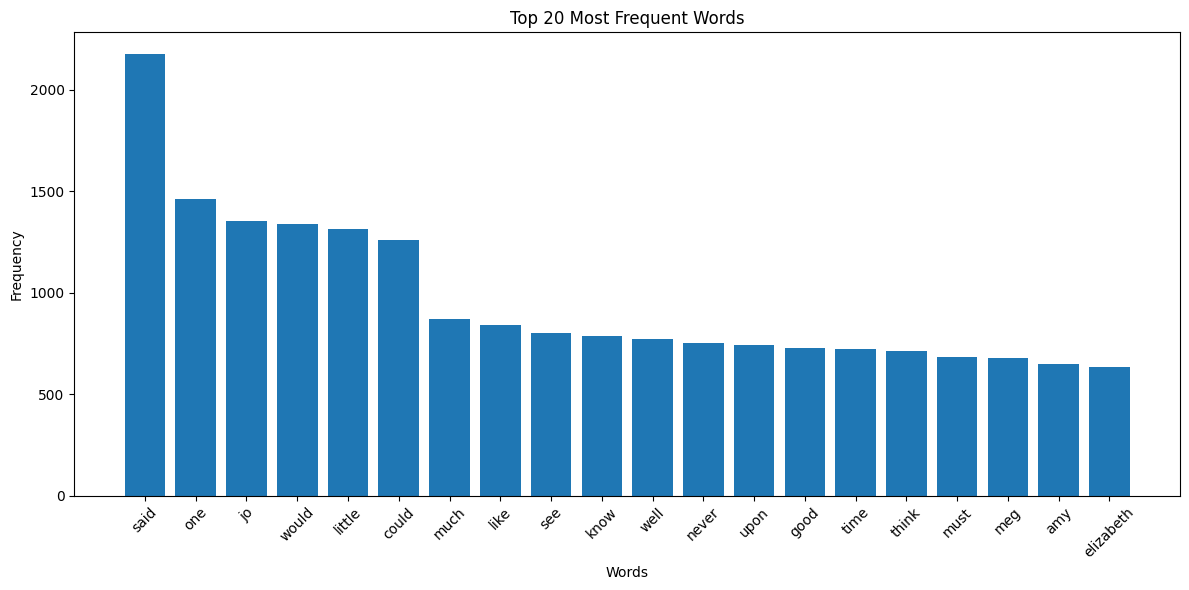

In [ ]:
words = [word for word, count in top_20_words]
counts = [count for word, count in top_20_words]

plt.figure(figsize=(12, 6))

plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

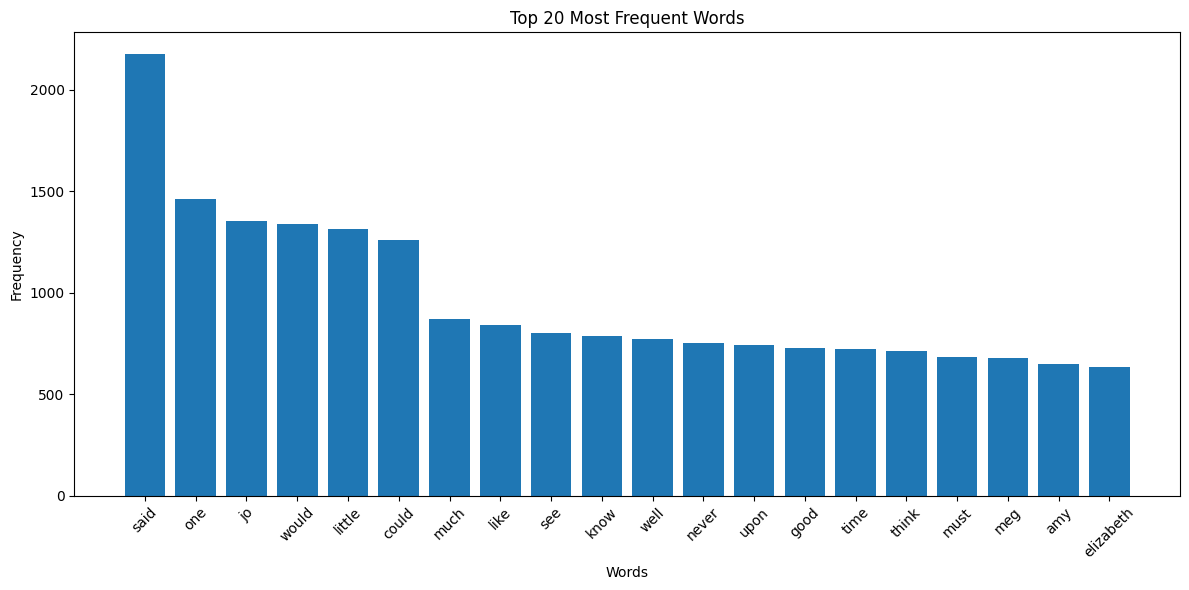

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("top_20_frequent_words.png", dpi=300, bbox_inches="tight")
plt.show()

###**Bigram Autocomplete Model**

In [ ]:
bigrams = list(ngrams(clean_tokens, 2))

print("Total bigrams:", len(bigrams))
print(bigrams[:20])

Total bigrams: 453652
[('the', 'project'), ('project', 'gutenberg'), ('gutenberg', 'ebook'), ('ebook', 'of'), ('of', 'pride'), ('pride', 'and'), ('and', 'prejudice'), ('prejudice', 'this'), ('this', 'ebook'), ('ebook', 'is'), ('is', 'for'), ('for', 'the'), ('the', 'use'), ('use', 'of'), ('of', 'anyone'), ('anyone', 'anywhere'), ('anywhere', 'in'), ('in', 'the'), ('the', 'united'), ('united', 'states')]


In [ ]:
bigram_counts = Counter(bigrams)

print("Unique bigrams:", len(bigram_counts))

Unique bigrams: 165188


In [ ]:
autocomplete_model = defaultdict(Counter)

for (word1, word2), count in bigram_counts.items():
    autocomplete_model[word1][word2] = count

print("Example predictions for 'said':")
print(autocomplete_model["said"].most_common(5))

Example predictions for 'said':
[('the', 259), ('he', 191), ('jo', 118), ('alice', 116), ('holmes', 112)]


In [ ]:
def autocomplete(word, n=3):
    word = word.lower()

    if word in autocomplete_model:
        return autocomplete_model[word].most_common(n)
    else:
        return []

In [ ]:
test_word = "said"

predictions = autocomplete(test_word)

print("Input:", test_word)
print("Top predictions:")

for word, count in predictions:
    print(word, ":", count)

Input: said
Top predictions:
the : 259
he : 191
jo : 118


In [ ]:
test_words = [
    "the",
    "said",
    "would",
    "could",
    "little",
    "one",
    "like",
    "know",
    "never",
    "good"
]

for word in test_words:
    print(f"\nInput: {word}")

    predictions = autocomplete(word, 3)

    if predictions:
        for predicted_word, count in predictions:
            print(f"  {predicted_word} ({count})")
    else:
        print("  No prediction available")


Input: the
  other (245)
  little (212)
  first (200)

Input: said
  the (259)
  he (191)
  jo (118)

Input: would
  be (234)
  have (211)
  not (150)

Input: could
  not (339)
  be (106)
  have (66)

Input: little
  girl (28)
  girls (26)
  of (25)

Input: one
  of (289)
  and (38)
  another (35)

Input: like
  a (182)
  to (106)
  the (56)

Input: know
  what (83)
  that (79)
  how (45)

Input: never
  had (28)
  mind (24)
  be (23)

Input: good
  deal (48)
  and (47)
  as (23)


In [ ]:
trigrams = list(ngrams(clean_tokens, 3))

print("Total trigrams:", len(trigrams))
print(trigrams[:20])

Total trigrams: 453651
[('the', 'project', 'gutenberg'), ('project', 'gutenberg', 'ebook'), ('gutenberg', 'ebook', 'of'), ('ebook', 'of', 'pride'), ('of', 'pride', 'and'), ('pride', 'and', 'prejudice'), ('and', 'prejudice', 'this'), ('prejudice', 'this', 'ebook'), ('this', 'ebook', 'is'), ('ebook', 'is', 'for'), ('is', 'for', 'the'), ('for', 'the', 'use'), ('the', 'use', 'of'), ('use', 'of', 'anyone'), ('of', 'anyone', 'anywhere'), ('anyone', 'anywhere', 'in'), ('anywhere', 'in', 'the'), ('in', 'the', 'united'), ('the', 'united', 'states'), ('united', 'states', 'and')]


###**Count the Trigrams**

In [ ]:
trigram_counts = Counter(trigrams)

print("Unique trigrams:", len(trigram_counts))

Unique trigrams: 351501


###**Trigram Autocomplete Model**

In [ ]:
trigram_model = defaultdict(Counter)

for (word1, word2, word3), count in trigram_counts.items():
    trigram_model[(word1, word2)][word3] = count

print("Number of two-word prefixes:", len(trigram_model))

Number of two-word prefixes: 165188


In [ ]:
def trigram_autocomplete(word1, word2, n=3):
    key = (word1.lower(), word2.lower())

    if key in trigram_model:
        return trigram_model[key].most_common(n)
    else:
        return []

In [ ]:
predictions = trigram_autocomplete("could", "not")

print("Input: could not")
print("Top predictions:")

for word, count in predictions:
    print(word, ":", count)

Input: could not
Top predictions:
be : 45
have : 33
help : 32


In [ ]:
test_phrases = [
    ("the", "project"),
    ("of", "the"),
    ("in", "the"),
    ("it", "was"),
    ("she", "was"),
    ("he", "said"),
    ("i", "am"),
    ("there", "was"),
    ("one", "of"),
    ("could", "not")
]

for word1, word2 in test_phrases:
    print(f"\nInput: {word1} {word2}")

    predictions = trigram_autocomplete(word1, word2, 3)

    if predictions:
        for predicted_word, count in predictions:
            print(f"  {predicted_word} ({count})")
    else:
        print("  No prediction available")


Input: the project
  gutenberg (108)
  trademark (8)
  concept (4)

Input: of the
  house (41)
  project (40)
  world (34)

Input: in the
  world (70)
  united (40)
  morning (40)

Input: it was
  a (112)
  not (66)
  the (34)

Input: she was
  a (29)
  not (21)
  in (19)

Input: he said
  that (13)
  to (10)
  in (10)

Input: i am
  sure (79)
  not (58)
  afraid (33)

Input: there was
  a (103)
  no (74)
  nothing (23)

Input: one of
  the (139)
  them (22)
  his (20)

Input: could not
  be (45)
  have (33)
  help (32)


###**Bigram vs Trigram**

In [ ]:
test_cases = [
    ("the", "project", "gutenberg"),
    ("of", "the", "house"),
    ("in", "the", "world"),
    ("it", "was", "a"),
    ("she", "was", "a"),
    ("he", "said", "that"),
    ("i", "am", "sure"),
    ("there", "was", "a"),
    ("one", "of", "the"),
    ("could", "not", "be")
]

bigram_correct = 0
trigram_correct = 0

for word1, word2, actual in test_cases:

    # Bigram prediction uses only the second word
    bigram_predictions = [word for word, count in autocomplete(word2, 3)]

    # Trigram prediction uses both words
    trigram_predictions = [word for word, count in trigram_autocomplete(word1, word2, 3)]

    if actual in bigram_predictions:
        bigram_correct += 1

    if actual in trigram_predictions:
        trigram_correct += 1

    print(f"\nInput: {word1} {word2}")
    print("Actual:", actual)
    print("Bigram:", bigram_predictions)
    print("Trigram:", trigram_predictions)

bigram_accuracy = bigram_correct / len(test_cases)
trigram_accuracy = trigram_correct / len(test_cases)

print("\n--- Results ---")
print("Bigram Top-3 Accuracy:", bigram_accuracy)
print("Trigram Top-3 Accuracy:", trigram_accuracy)


Input: the project
Actual: gutenberg
Bigram: ['gutenberg', 'electronic', 'license']
Trigram: ['gutenberg', 'trademark', 'concept']

Input: of the
Actual: house
Bigram: ['other', 'little', 'first']
Trigram: ['house', 'project', 'world']

Input: in the
Actual: world
Bigram: ['other', 'little', 'first']
Trigram: ['world', 'united', 'morning']

Input: it was
Actual: a
Bigram: ['a', 'not', 'the']
Trigram: ['a', 'not', 'the']

Input: she was
Actual: a
Bigram: ['a', 'not', 'the']
Trigram: ['a', 'not', 'in']

Input: he said
Actual: that
Bigram: ['the', 'he', 'jo']
Trigram: ['that', 'to', 'in']

Input: i am
Actual: sure
Bigram: ['sure', 'not', 'i']
Trigram: ['sure', 'not', 'afraid']

Input: there was
Actual: a
Bigram: ['a', 'not', 'the']
Trigram: ['a', 'no', 'nothing']

Input: one of
Actual: the
Bigram: ['the', 'her', 'a']
Trigram: ['the', 'them', 'his']

Input: could not
Actual: be
Bigram: ['be', 'to', 'a']
Trigram: ['be', 'have', 'help']

--- Results ---
Bigram Top-3 Accuracy: 0.7
Trigram To

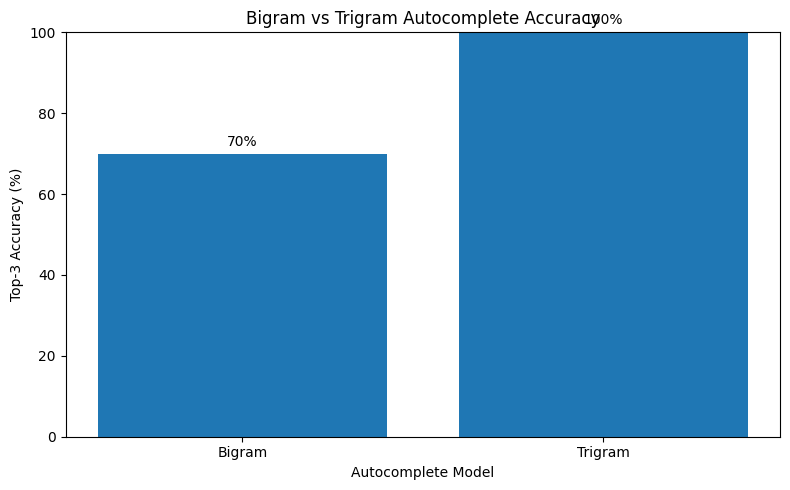

In [ ]:
models = ["Bigram", "Trigram"]
accuracies = [bigram_accuracy * 100, trigram_accuracy * 100]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.title("Bigram vs Trigram Autocomplete Accuracy")
plt.xlabel("Autocomplete Model")
plt.ylabel("Top-3 Accuracy (%)")
plt.ylim(0, 100)

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 2, f"{accuracy:.0f}%", ha="center")

plt.tight_layout()
plt.show()

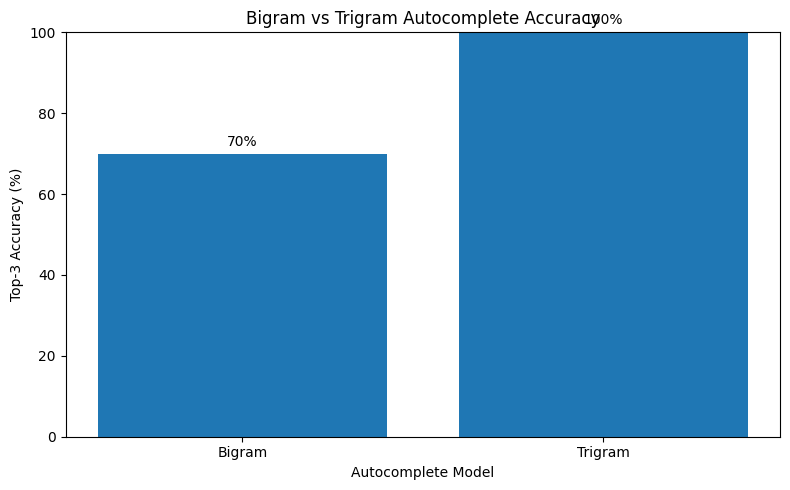

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.title("Bigram vs Trigram Autocomplete Accuracy")
plt.xlabel("Autocomplete Model")
plt.ylabel("Top-3 Accuracy (%)")
plt.ylim(0, 100)

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 2, f"{accuracy:.0f}%", ha="center")

plt.tight_layout()
plt.savefig("bigram_vs_trigram_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
misspelled_words = [
    "recieve",
    "becuase",
    "definately",
    "seperate",
    "occured",
    "adress",
    "acheive",
    "begining",
    "enviroment",
    "goverment",
    "teh",
    "wierd",
    "untill",
    "succesful",
    "tommorow",
    "beleive",
    "freind",
    "occassion",
    "responsibile",
    "experiance"
]

correct_words = [
    "receive",
    "because",
    "definitely",
    "separate",
    "occurred",
    "address",
    "achieve",
    "beginning",
    "environment",
    "government",
    "the",
    "weird",
    "until",
    "successful",
    "tomorrow",
    "believe",
    "friend",
    "occasion",
    "responsible",
    "experience"
]

print("Total misspelled words:", len(misspelled_words))

Total misspelled words: 20


###**Apply SpellChecker Autocorrection**

In [ ]:
spell = SpellChecker()

corrected_words = []

for word in misspelled_words:
    corrected = spell.correction(word)
    corrected_words.append(corrected)

for wrong, corrected in zip(misspelled_words, corrected_words):
    print(f"{wrong} → {corrected}")

recieve → receive
becuase → because
definately → definitely
seperate → separate
occured → occurred
adress → dress
acheive → achieve
begining → beginning
enviroment → environment
goverment → government
teh → the
wierd → weird
untill → until
succesful → successful
tommorow → tomorrow
beleive → believe
freind → friend
occassion → occasion
responsibile → responsible
experiance → experience


In [ ]:
correct_count = sum(
    predicted == actual
    for predicted, actual in zip(corrected_words, correct_words)
)

total_words = len(correct_words)

accuracy = correct_count / total_words

print("Correct corrections:", correct_count)
print("Total test words:", total_words)
print(f"Autocorrect Accuracy: {accuracy:.2%}")

Correct corrections: 19
Total test words: 20
Autocorrect Accuracy: 95.00%


In [ ]:
true_positives = correct_count
false_positives = total_words - correct_count
false_negatives = total_words - correct_count

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Precision: 95.00%
Recall: 95.00%


In [ ]:
correct_test_words = [
    "receive",
    "because",
    "definitely",
    "separate",
    "occurred",
    "address",
    "achieve",
    "beginning",
    "environment",
    "government",
    "the",
    "weird",
    "until",
    "successful",
    "tomorrow",
    "believe",
    "friend",
    "occasion",
    "responsible",
    "experience"
]

corrected_test_words = [
    spell.correction(word) for word in correct_test_words
]

for word, corrected in zip(correct_test_words, corrected_test_words):
    print(f"{word} → {corrected}")

receive → receive
because → because
definitely → definitely
separate → separate
occurred → occurred
address → address
achieve → achieve
beginning → beginning
environment → environment
government → government
the → the
weird → weird
until → until
successful → successful
tomorrow → tomorrow
believe → believe
friend → friend
occasion → occasion
responsible → responsible
experience → experience


###**Confusion Matrix**

Confusion Matrix:
[[19  1]
 [20  0]]


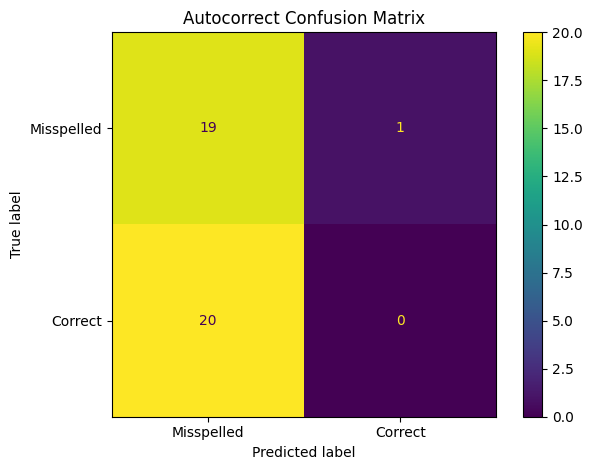

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Actual labels: 1 = misspelled, 0 = correctly spelled
actual_labels = [1] * len(misspelled_words) + [0] * len(correct_test_words)

# Predicted labels:
# 1 = correctly handled, 0 = incorrectly handled
predicted_labels = [
    int(pred == actual)
    for pred, actual in zip(corrected_words, correct_words)
] + [
    int(pred == actual)
    for pred, actual in zip(corrected_test_words, correct_test_words)
]

cm = confusion_matrix(actual_labels, predicted_labels, labels=[1, 0])

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Misspelled", "Correct"]
)

disp.plot()
plt.title("Autocorrect Confusion Matrix")
plt.tight_layout()
plt.show()

###**Autocomplete Precision & Recall**

In [ ]:
total_cases = len(test_cases)

bigram_hits = bigram_correct
trigram_hits = trigram_correct

bigram_precision = bigram_hits / (total_cases * 3)
bigram_recall = bigram_hits / total_cases

trigram_precision = trigram_hits / (total_cases * 3)
trigram_recall = trigram_hits / total_cases

print("Autocomplete Evaluation")
print("------------------------")

print(f"Bigram Precision@3: {bigram_precision:.2%}")
print(f"Bigram Recall@3: {bigram_recall:.2%}")

print(f"\nTrigram Precision@3: {trigram_precision:.2%}")
print(f"Trigram Recall@3: {trigram_recall:.2%}")

Autocomplete Evaluation
------------------------
Bigram Precision@3: 23.33%
Bigram Recall@3: 70.00%

Trigram Precision@3: 33.33%
Trigram Recall@3: 100.00%


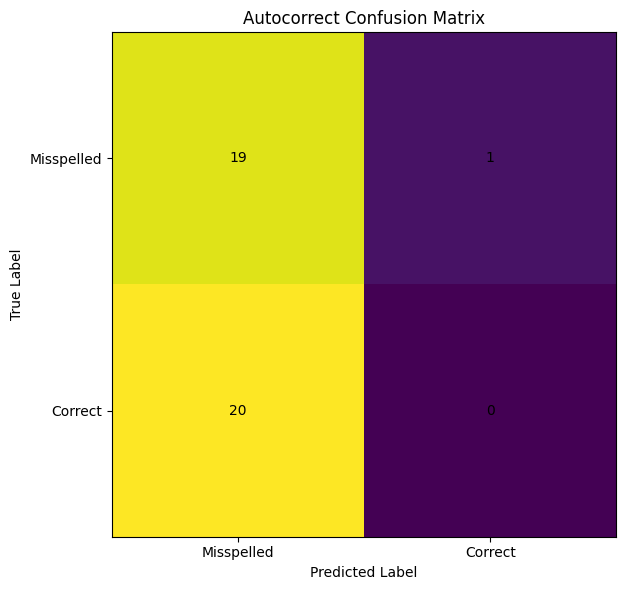

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Autocorrect Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Misspelled", "Correct"])
plt.yticks([0, 1], ["Misspelled", "Correct"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("autocorrect_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

###**Compare Bigram and Trigram Models**

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Bigram", "Trigram"],
    "Top-3 Accuracy": [bigram_accuracy, trigram_accuracy],
    "Precision@3": [bigram_precision, trigram_precision],
    "Recall@3": [bigram_recall, trigram_recall]
})

comparison["Top-3 Accuracy"] = comparison["Top-3 Accuracy"] * 100
comparison["Precision@3"] = comparison["Precision@3"] * 100
comparison["Recall@3"] = comparison["Recall@3"] * 100

print(comparison)

     Model  Top-3 Accuracy  Precision@3  Recall@3
0   Bigram            70.0    23.333333      70.0
1  Trigram           100.0    33.333333     100.0


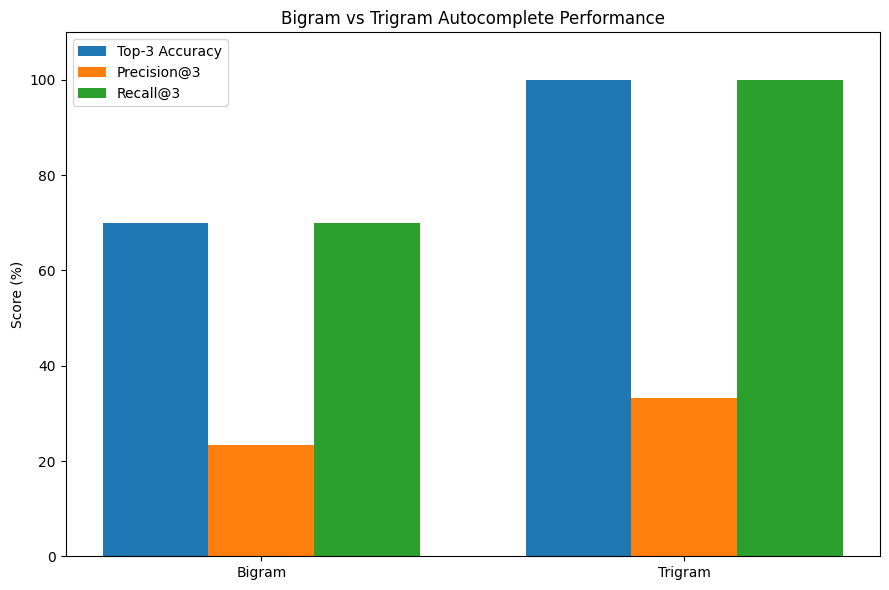

In [ ]:
plt.figure(figsize=(9, 6))

x = np.arange(len(comparison["Model"]))
width = 0.25

plt.bar(x - width, comparison["Top-3 Accuracy"], width, label="Top-3 Accuracy")
plt.bar(x, comparison["Precision@3"], width, label="Precision@3")
plt.bar(x + width, comparison["Recall@3"], width, label="Recall@3")

plt.xticks(x, comparison["Model"])
plt.ylabel("Score (%)")
plt.title("Bigram vs Trigram Autocomplete Performance")
plt.ylim(0, 110)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
autocorrect_accuracy = correct_count / total_words

print("Autocorrect Evaluation")
print("----------------------")
print(f"Accuracy:  {autocorrect_accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")

Autocorrect Evaluation
----------------------
Accuracy:  95.00%
Precision: 95.00%
Recall:    95.00%


In [ ]:
final_results = pd.DataFrame({
    "System": [
        "Bigram Autocomplete",
        "Trigram Autocomplete",
        "Autocorrect"
    ],
    "Accuracy": [
        bigram_accuracy,
        trigram_accuracy,
        autocorrect_accuracy
    ],
    "Precision": [
        bigram_precision,
        trigram_precision,
        precision
    ],
    "Recall": [
        bigram_recall,
        trigram_recall,
        recall
    ]
})

final_results["Accuracy"] = final_results["Accuracy"] * 100
final_results["Precision"] = final_results["Precision"] * 100
final_results["Recall"] = final_results["Recall"] * 100

print(final_results.round(2))

                 System  Accuracy  Precision  Recall
0   Bigram Autocomplete      70.0      23.33    70.0
1  Trigram Autocomplete     100.0      33.33   100.0
2           Autocorrect      95.0      95.00    95.0


## **Discussion and Limitations**

The results show that the trigram autocomplete model performed better than the bigram model on the selected test cases. The trigram model achieved 100% Top-3 accuracy and 100% Recall@3, compared with 70% for the bigram model. This improvement is mainly because the trigram model considers two previous words as context when predicting the next word.

The autocorrect system achieved 95% accuracy, precision, and recall on the 20 deliberately misspelled words. It correctly corrected 19 out of 20 misspellings, while all 20 correctly spelled control words remained unchanged.

However, the models have several limitations. The autocomplete models are frequency-based and depend heavily on the words present in the training corpus. They may perform poorly for rare words, unseen phrases, new topics, or different writing styles. The test set for autocomplete is also small, containing only 10 test cases, so the reported accuracy should not be considered representative of real-world performance.

The autocorrect evaluation used only 20 misspelled words, so a larger and more diverse test set would provide a more reliable evaluation. The SpellChecker approach also does not fully understand the context of a sentence, which can lead to incorrect corrections when multiple words are possible.

Production systems such as Google Keyboard use much larger datasets, contextual language models, personalization, and more advanced machine learning or neural network techniques. Therefore, the models developed in this project are simplified implementations intended to demonstrate the basic concepts of autocomplete and autocorrect.

## **Conclusion**

This project analyzed the basic concepts of autocomplete and autocorrect using a large text corpus collected from Project Gutenberg.

For autocomplete, two frequency-based NLP models were implemented: a Bigram model and a Trigram model. The Bigram model achieved 70% Top-3 accuracy, while the Trigram model achieved 100% Top-3 accuracy on the selected test cases. The Trigram model also achieved higher Precision@3 and Recall@3, demonstrating the benefit of using additional word context for next-word prediction.

For autocorrect, the SpellChecker-based approach was tested on 20 deliberately misspelled words. It correctly corrected 19 out of 20 words, achieving 95% accuracy, precision, and recall. Additionally, all 20 correctly spelled control words remained unchanged.

Overall, the results demonstrate that using contextual information improves autocomplete performance, while dictionary-based spelling correction can effectively handle common spelling mistakes. Although these implementations are simpler than production systems, the project provides a practical understanding of NLP preprocessing, n-gram modeling, spelling correction, evaluation metrics, and performance visualization.